In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
claims = pd.read_csv("/content/clean_claims_data (1).csv", low_memory=False)
print(claims.shape)
claims.head()

(21571, 47)


,BeneID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,ClmDiagnosisCode_1,...,Race_5,Gender,Race,Race_1.1,Race_2.1,Race_3.1,Race_5.1,num_diagnosis_codes,num_procedure_codes,chornic_count
0,BENE11001,PRV55912,26000,PHY390922,NaN,NaN,7866,1068.0,201,1970,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,BENE11001,PRV55907,5000,PHY318495,PHY318495,NaN,6186,1068.0,750,6186,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,BENE11001,PRV56046,5000,PHY372395,NaN,PHY324689,29590,1068.0,883,29623,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,BENE11011,PRV52405,5000,PHY369659,PHY392961,PHY349768,431,1068.0,067,43491,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,BENE11014,PRV56614,10000,PHY379376,PHY398258,NaN,78321,1068.0,975,042,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [3]:
y = claims['PotentialFraud']
x = claims.drop(columns=['PotentialFraud'])

In [4]:
drop_cols = [
    "BeneID",
    "ClaimID",
    "Provider",
    "AttendingPhysician",
    "OperatingPhysician",
    "OtherPhysician",
    "ClmAdmitDiagnosisCode",
    "fraud_ratio",
]

x = x.drop(columns=drop_cols, errors="ignore")
print(f"Columns after dropping IDs and leaky features: {x.shape[1]}")

Columns after dropping IDs and leaky features: 39


In [5]:
diag_cols = [col for col in x.columns if 'ClmDiagnosisCode' in col]
x = x.drop(columns=diag_cols)

proc_cols = [col for col in x.columns if 'ClmProcedureCode' in col]
x = x.drop(columns=proc_cols, errors='ignore')

print(f"Shape after dropping diagnosis/procedure codes: {x.shape}")

Shape after dropping diagnosis/procedure codes: (21571, 23)


In [6]:

before = x.shape[1]
x = x.T.drop_duplicates().T
print(f"Dropped {before - x.shape[1]} duplicate columns. Shape: {x.shape}")
print(f"Remaining columns: {x.columns.tolist()}")

Dropped 5 duplicate columns. Shape: (21571, 18)
Remaining columns: ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'DiagnosisGroupCode', 'claim_type', 'claimDuration', 'HospitalStayDays', 'PatientAge', 'total_claims', 'unique_doctors', 'avg_claim_amount', 'Race_1', 'Race_2', 'Race_3', 'Race_5', 'Gender', 'Race', 'num_diagnosis_codes', 'num_procedure_codes']


In [7]:
print("Null counts (top 10):")
print(x.isnull().sum().sort_values(ascending=False).head(10))

Null counts (top 10):
DeductibleAmtPaid         467
num_procedure_codes         1
Race_5                      1
num_diagnosis_codes         1
Race                        1
Gender                      1
Race_2                      1
Race_3                      1
Race_1                      1
InscClaimAmtReimbursed      0
dtype: int64


In [8]:
# Drop DiagnosisGroupCode (too many nulls)
x = x.drop(columns=['DiagnosisGroupCode'], errors='ignore')

# Fill HospitalStayDays nulls with 0 (outpatient claims have no hospital stay)
if 'HospitalStayDays' in x.columns:
    x['HospitalStayDays'] = x['HospitalStayDays'].fillna(0)

# Fill DeductibleAmtPaid nulls with median
if 'DeductibleAmtPaid' in x.columns:
    x['DeductibleAmtPaid'] = x['DeductibleAmtPaid'].fillna(x['DeductibleAmtPaid'].median())

/tmp/ipykernel_181/1479585330.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['HospitalStayDays'] = x['HospitalStayDays'].fillna(0)
/tmp/ipykernel_181/1479585330.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['DeductibleAmtPaid'] = x['DeductibleAmtPaid'].fillna(x['DeductibleAmtPaid'].median())


In [9]:
# Encode claim_type: inpatient=1, outpatient=0
if 'claim_type' in x.columns:
    x['claim_type'] = x['claim_type'].map({'inpatient': 1, 'outpatient': 0})

# Encode any remaining object columns
from sklearn.preprocessing import LabelEncoder

remaining_str_cols = x.select_dtypes(include='object').columns.tolist()
if remaining_str_cols:
    print(f"Encoding remaining string columns: {remaining_str_cols}")
    for col in remaining_str_cols:
        x[col] = LabelEncoder().fit_transform(x[col].astype(str))
else:
    print("No remaining string columns — all good!")

print("\nFinal dtypes:")
print(x.dtypes.value_counts())
print(f"\nFinal shape: {x.shape}")

Encoding remaining string columns: ['InscClaimAmtReimbursed', 'claimDuration', 'PatientAge', 'total_claims', 'unique_doctors', 'avg_claim_amount', 'Race_1', 'Race_2', 'Race_3', 'Race_5', 'Gender', 'Race', 'num_diagnosis_codes', 'num_procedure_codes']

Final dtypes:
int64      15
float64     2
Name: count, dtype: int64

Final shape: (21571, 17)


In [10]:
from sklearn.model_selection import train_test_split

# Drop rows where y is NaN to enable stratification
nan_in_y_mask = y.isna()
if nan_in_y_mask.any():
    print(f"Dropping {nan_in_y_mask.sum()} rows due to NaN values in 'y'.")
    x = x[~nan_in_y_mask]
    y = y[~nan_in_y_mask]

# ✅ Step 1: Split FIRST — before imputation or SMOTE
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {x_train.shape}, Test size: {x_test.shape}")
print(f"\nClass balance in train set:")
print(y_train.value_counts(normalize=True))

Train size: (17256, 17), Test size: (4315, 17)

Class balance in train set:
PotentialFraud
1    0.575974
0    0.424026
Name: proportion, dtype: float64


In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ✅ Step 2: Impute AFTER split — fit only on train to prevent leakage
imputer = SimpleImputer(strategy='median')
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed  = imputer.transform(x_test)  # transform only, no fit!

# ✅ Step 3: SMOTE only on training data — never touch test set
# Note: class balance is already ~50/50, SMOTE has minimal effect here
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train_imputed, y_train)

print(f"After SMOTE — Train size: {x_train_sm.shape}")
print(f"Class distribution:\n{pd.Series(y_train_sm).value_counts()}")

After SMOTE — Train size: (19878, 17)
Class distribution:
PotentialFraud
0    9939
1    9939
Name: count, dtype: int64


In [12]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(x_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(x_test_imputed)
y_prob = model.predict_proba(x_test_imputed)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Confusion Matrix:
[[1627  203]
 [ 228 2257]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1830
           1       0.92      0.91      0.91      2485

    accuracy                           0.90      4315
   macro avg       0.90      0.90      0.90      4315
weighted avg       0.90      0.90      0.90      4315

ROC AUC Score: 0.9650


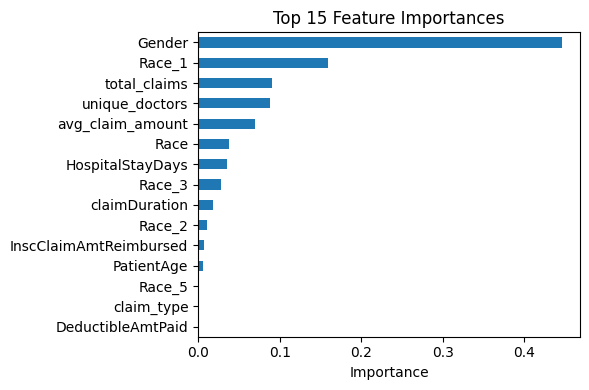

In [14]:
import matplotlib.pyplot as plt

# Get feature importances
feature_names = x.T.drop_duplicates().T.drop(
    columns=['DiagnosisGroupCode'] +
    [col for col in x.columns if 'ClmDiagnosisCode' in col or 'ClmProcedureCode' in col],
    errors='ignore'
).columns.tolist()

importances = model.feature_importances_
n = min(len(importances), len(feature_names))

fi = pd.Series(importances[:n], index=feature_names[:n]).sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 4))
fi.plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
pip install shap

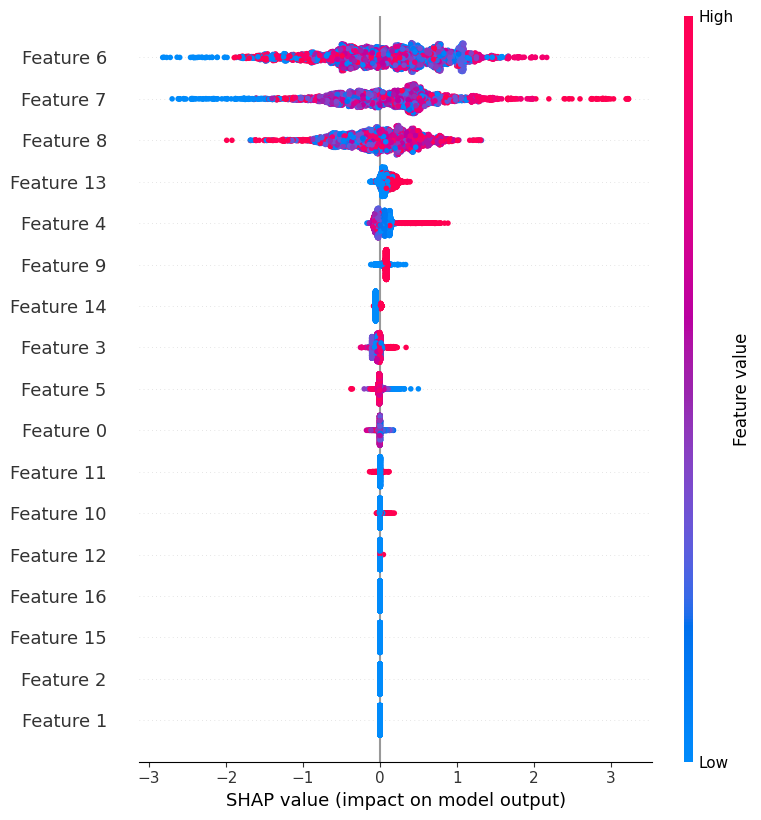

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_imputed)

shap.summary_plot(shap_values, x_test_imputed)

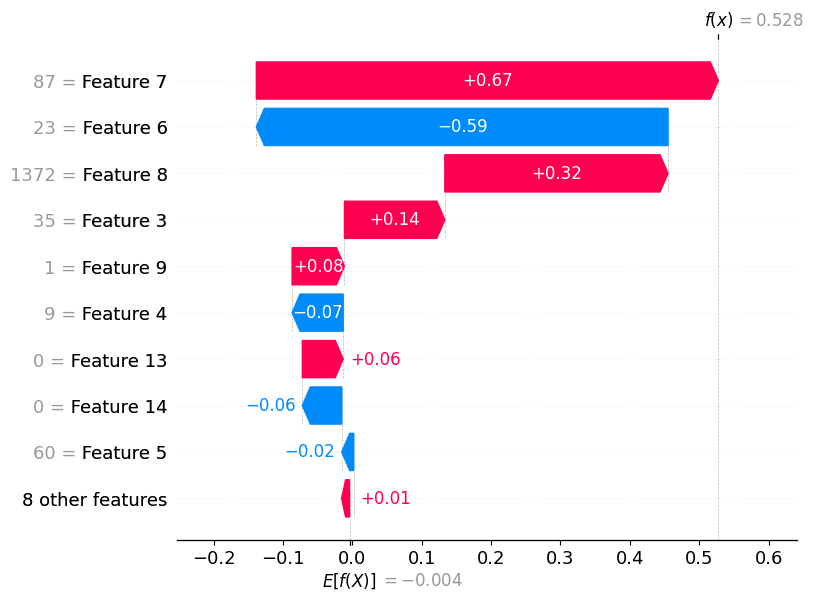

In [17]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values = explainer.expected_value,
        data=x_test_imputed[0]
    )
)

In [18]:
avg_fraud_claim = x_test['InscClaimAmtReimbursed'].mean()

fraud_cases_detected = sum((y_test == 1) & (y_pred == 1))

estimated_savings = fraud_cases_detected * avg_fraud_claim

print("Average fraudulent claim amount:", avg_fraud_claim)
print("Frauds detected:", fraud_cases_detected)
print("Estimated prevented loss:", estimated_savings)

Average fraudulent claim amount: 53.781228273464656
Frauds detected: 2257
Estimated prevented loss: 121384.23221320973


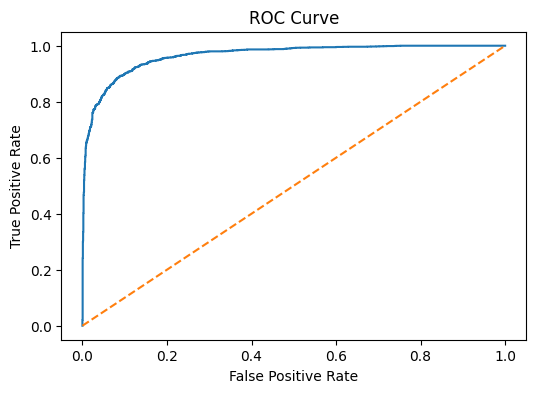

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [20]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']